<div style="text-align:center; margin-top:40px;">

<img src="img/python_logo.png" width="600"/>

<h1 style="
font-family:'Times New Roman', serif;
font-size:42px;
font-weight:bold;
margin-bottom:10px;
">

Programa15.Clasificacion.LOGR

</h1>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
">

July 17, 2026

</p>

<h2 style="
font-family:'Times New Roman', serif;
font-size:28px;
font-weight:bold;
margin-top:35px;
">

PAO25-25 - REGRESIÓN LOGÍSTICA

</h2>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
margin-bottom:8px;
">

Kevin Suasnavas

</p>

<p style="
font-family:'Times New Roman', serif;
font-size:18px;
margin-top:0px;
">

<a href="https://github.com/kevinsuas433/Machine2026.git">
<strong>Link a mi GitHub:</strong>
</a>

https://github.com/kevinsuas433/Machine2026.git

</p>

</div>

---

# 1. Importación de librerías

En esta sección se importan las librerías necesarias para desarrollar un modelo de **Regresión Logística**. Estas bibliotecas permiten cargar el conjunto de datos, dividir la información en entrenamiento y prueba, estandarizar las variables, entrenar el modelo y evaluar su desempeño mediante diferentes métricas de clasificación.

In [2]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

# NumPy se utiliza para trabajar con arreglos y operaciones
# matemáticas.
import numpy as np

# Se importa el módulo de métricas de Scikit-Learn para
# evaluar el rendimiento del modelo de clasificación.
import sklearn.metrics as metrics

# Se carga el conjunto de datos Iris.
from sklearn.datasets import load_iris

# Se importa el algoritmo de Regresión Logística.
from sklearn.linear_model import LogisticRegression

# Herramientas para dividir los datos y realizar
# validación cruzada.
from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    cross_val_score,
    KFold
)

# Librería utilizada para estandarizar las variables.
from sklearn import preprocessing

# Librería para realizar gráficos.
import matplotlib.pyplot as plt


# 2. Carga del conjunto de datos

En esta práctica se utiliza el conjunto de datos **Iris**, uno de los conjuntos de datos más conocidos en aprendizaje automático.

Para facilitar la visualización de los resultados, únicamente se emplean los dos últimos atributos del conjunto de datos, correspondientes a las medidas del pétalo de cada flor.

In [3]:
# ==========================================================
# CARGA DEL CONJUNTO DE DATOS
# ==========================================================

# Se carga el conjunto de datos Iris.
datos = load_iris()

# Se seleccionan únicamente las dos últimas características
# (longitud y ancho del pétalo).
X = datos.data[:, 2:]

# Variable objetivo que contiene la especie de cada flor.
y = datos.target

# Se muestran las dimensiones del conjunto de datos.
print("Dimensiones de X:", np.shape(X))

Dimensiones de X: (150, 2)


# 3. Definición de métricas de evaluación

Para evaluar el desempeño del clasificador se utilizarán las siguientes métricas:

- **Accuracy (ACC):** porcentaje de predicciones correctas.
- **Precision (PREC):** proporción de predicciones positivas correctas.
- **Recall:** capacidad del modelo para identificar correctamente los casos positivos.
- **F1-Score:** media armónica entre precisión y recall.

In [4]:
# ==========================================================
# MÉTRICAS DE EVALUACIÓN
# ==========================================================

# Se define un diccionario con las métricas que serán
# utilizadas durante la evaluación del modelo.
metricas = {

    # Exactitud del modelo.
    'ACC': metrics.accuracy_score,

    # Precisión.
    'PREC': lambda y_true, y_pred:
        metrics.precision_score(
            y_true,
            y_pred,
            average='micro'
        ),

    # Sensibilidad o Recall.
    'RECALL': lambda y_true, y_pred:
        metrics.recall_score(
            y_true,
            y_pred,
            average='micro'
        ),

    # Puntaje F1.
    'F1': lambda y_true, y_pred:
        metrics.f1_score(
            y_true,
            y_pred,
            average='micro'
        )
}

# 4. Partición del conjunto de datos

El conjunto de datos se divide en dos subconjuntos:

- **80 %** para el entrenamiento del modelo.
- **20 %** para evaluar su rendimiento con datos no utilizados durante el aprendizaje.

Esta estrategia permite medir la capacidad de generalización del clasificador.

In [5]:
# ==========================================================
# PARTICIÓN DEL CONJUNTO DE DATOS
# ==========================================================

# Se divide el conjunto de datos en entrenamiento (80%)
# y prueba (20%).
X_training, X_testing, y_training, y_testing = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Se muestran las dimensiones del conjunto de entrenamiento.
print("Dimensiones de X_training:", np.shape(X_training))

Dimensiones de X_training: (120, 2)


# 5. Preparación de los datos de entrenamiento

Antes de entrenar el modelo, las variables del conjunto de entrenamiento se estandarizan para que todas tengan una escala similar.

Este proceso mejora la estabilidad del algoritmo y favorece una convergencia más rápida durante el aprendizaje.

In [7]:
# ==========================================================
# ESTANDARIZACIÓN DE LOS DATOS DE ENTRENAMIENTO
# ==========================================================

# Se crea el objeto encargado de estandarizar los datos.
standardizer = preprocessing.StandardScaler()

# Se ajusta el estandarizador con los datos de entrenamiento
# y posteriormente se transforman.
X_stdr = standardizer.fit_transform(X_training)

# Muestra los datos estandarizados.
print(X_stdr)

[[-1.56253475 -1.31260282]
 [-1.27600637 -1.04563275]
 [ 0.38585821  0.28921757]
 [-1.2187007  -1.31260282]
 [-1.39061772 -1.31260282]
 [ 0.72969227  0.95664273]
 [ 0.44316389  0.4227026 ]
 [-1.27600637 -1.31260282]
 [-1.33331205 -1.31260282]
 [-1.27600637 -1.44608785]
 [ 0.78699794  0.95664273]
 [ 0.44316389  0.55618763]
 [ 0.55777524  0.4227026 ]
 [-1.39061772 -1.04563275]
 [-1.27600637 -1.31260282]
 [-0.01528151 -0.24472256]
 [ 0.78699794  0.4227026 ]
 [ 1.01622064  0.8231577 ]
 [ 0.38585821  0.28921757]
 [ 1.3600547   1.75755292]
 [ 0.27124686  0.15573254]
 [ 1.64658307  1.22361279]
 [ 0.44316389  0.4227026 ]
 [-1.33331205 -1.31260282]
 [ 1.70388875  1.09012776]
 [ 0.21394119 -0.24472256]
 [-1.33331205 -1.31260282]
 [-1.39061772 -1.17911778]
 [-1.04678367 -1.04563275]
 [-0.12989286 -0.24472256]
 [ 0.67238659  0.8231577 ]
 [-1.04678367 -1.31260282]
 [-1.2187007  -1.31260282]
 [-1.16139502 -0.91214772]
 [ 0.27124686  0.15573254]
 [-1.27600637 -1.31260282]
 [ 0.27124686  0.02224751]
 

# 6. Construcción del modelo de Regresión Logística

En esta etapa se define el algoritmo de aprendizaje que será utilizado para clasificar las observaciones del conjunto de datos.

El modelo de Regresión Logística permitirá identificar la clase correspondiente a cada muestra a partir de las características seleccionadas.

In [8]:
# ==========================================================
# CONSTRUCCIÓN DEL MODELO
# ==========================================================

# Se crea un diccionario que almacena el modelo de
# Regresión Logística y sus principales parámetros.
algoritmos = {
    'LOGR': LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=1000,
        random_state=42
    )
}

# 7. Validación cruzada

La validación cruzada permite estimar el desempeño del clasificador utilizando diferentes particiones del conjunto de entrenamiento.

En esta práctica se emplea una validación cruzada de **10 particiones (10-Fold Cross Validation)** para obtener predicciones y calcular las métricas de evaluación del modelo.

In [11]:
# ==========================================================
# VALIDACIÓN CRUZADA DEL MODELO
# ==========================================================

# Diccionario donde se almacenarán las predicciones.
y_pred = {}

# Se realiza la validación cruzada para cada algoritmo.
for nombre, alg in algoritmos.items():

    # Se obtienen las predicciones mediante validación cruzada.
    y_pred[nombre] = cross_val_predict(
        alg,
        X_stdr,
        y_training,
        cv=KFold(
            n_splits=10,
            shuffle=True,
            random_state=42
        )
    )

    # Se calcula la matriz de confusión.
    matriz = metrics.confusion_matrix(
        y_training,
        y_pred[nombre]
    )

    # Se calculan las métricas de evaluación.
    results = {
        "ACC": metrics.accuracy_score(y_training, y_pred[nombre]),
        "PREC": metrics.precision_score(y_training, y_pred[nombre], average="micro"),
        "RECALL": metrics.recall_score(y_training, y_pred[nombre], average="micro"),
        "F1": metrics.f1_score(y_training, y_pred[nombre], average="micro")
    }

    print("Matriz de confusión:")
    print(matriz)

    print("\nMétricas de evaluación:")
    for metrica, valor in results.items():
        print(f"{metrica}: {valor:.4f}")

Matriz de confusión:
[[40  0  0]
 [ 0 38  3]
 [ 0  4 35]]

Métricas de evaluación:
ACC: 0.9417
PREC: 0.9417
RECALL: 0.9417
F1: 0.9417


# 8. Entrenamiento del modelo

Una vez validado el algoritmo, se entrena el modelo definitivo utilizando todo el conjunto de entrenamiento estandarizado.

Este modelo será posteriormente utilizado para realizar las predicciones sobre el conjunto de prueba.

In [12]:
# ==========================================================
# ENTRENAMIENTO DEL MODELO
# ==========================================================

# Se entrena el modelo definitivo utilizando todos
# los datos de entrenamiento.
model = algoritmos["LOGR"].fit(
    X_stdr,
    y_training
)

# 9. Visualización de las fronteras de decisión

Para comprender el comportamiento del clasificador, se representa gráficamente la frontera de decisión generada por el modelo.

Esta visualización permite observar cómo el algoritmo separa las diferentes clases presentes en el conjunto de datos.

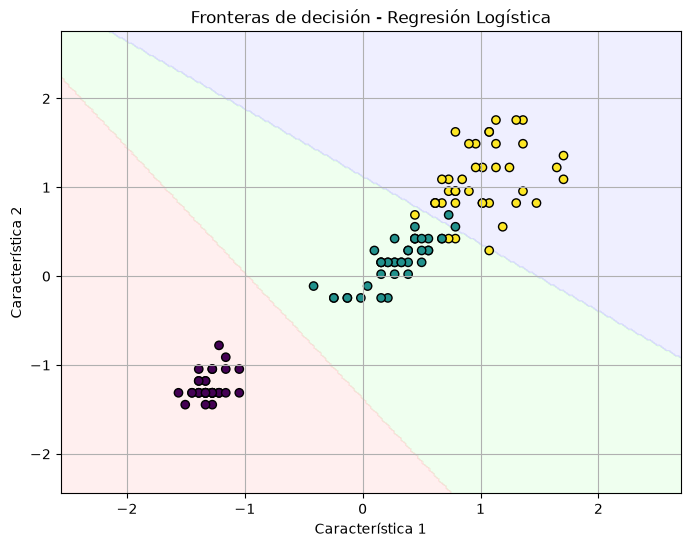

In [13]:
# ==========================================================
# VISUALIZACIÓN DE LAS FRONTERAS DE DECISIÓN
# ==========================================================

from matplotlib.colors import ListedColormap

# Se define una malla de puntos para representar
# la superficie de decisión.
x_min, x_max = X_stdr[:, 0].min() - 1, X_stdr[:, 0].max() + 1
y_min, y_max = X_stdr[:, 1].min() - 1, X_stdr[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Se predice la clase para cada punto de la malla.
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Se dibuja la frontera de decisión.
plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap=ListedColormap(["#FFCCCC", "#CCFFCC", "#CCCCFF"])
)

# Se representan las muestras del conjunto de entrenamiento.
plt.scatter(
    X_stdr[:, 0],
    X_stdr[:, 1],
    c=y_training,
    edgecolor="black"
)

plt.title("Fronteras de decisión - Regresión Logística")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.grid(True)

plt.show()

# 10. Preparación del conjunto de prueba

Antes de realizar las predicciones, el conjunto de datos de prueba debe ser transformado utilizando el mismo estandarizador empleado durante el entrenamiento.

De esta forma, tanto los datos de entrenamiento como los de prueba mantienen la misma escala, garantizando un comportamiento consistente del modelo.

In [14]:
# ==========================================================
# ESTANDARIZACIÓN DEL CONJUNTO DE PRUEBA
# ==========================================================

# Se transforman los datos del conjunto de prueba utilizando
# el estandarizador ajustado con los datos de entrenamiento.
X_test_stdr = standardizer.transform(X_testing)

# 11. Predicción del modelo

Una vez preparados los datos de prueba, el modelo de Regresión Logística realiza la predicción de la clase correspondiente para cada observación.

In [15]:
# ==========================================================
# PREDICCIÓN DEL CONJUNTO DE PRUEBA
# ==========================================================

# Se realizan las predicciones sobre el conjunto de prueba.
y_pred_test = model.predict(X_test_stdr)

# Se muestran las clases predichas.
print("Predicciones:")
print(y_pred_test)

Predicciones:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# 12. Evaluación del modelo

El desempeño del clasificador se evalúa utilizando las métricas de clasificación y la matriz de confusión.

Estas métricas permiten conocer qué tan bien el modelo clasifica las observaciones del conjunto de prueba.

In [16]:
# ==========================================================
# EVALUACIÓN DEL MODELO
# ==========================================================

# Se calculan las métricas de clasificación.
results = {
    "ACC": metrics.accuracy_score(y_testing, y_pred_test),
    "PREC": metrics.precision_score(y_testing, y_pred_test, average="micro"),
    "RECALL": metrics.recall_score(y_testing, y_pred_test, average="micro"),
    "F1": metrics.f1_score(y_testing, y_pred_test, average="micro")
}

# Se imprime cada una de las métricas.
print("Métricas de evaluación:\n")

for metrica, valor in results.items():
    print(f"{metrica}: {valor:.4f}")

# Se calcula e imprime la matriz de confusión.
print("\nMatriz de confusión:")
print(metrics.confusion_matrix(y_testing, y_pred_test))

Métricas de evaluación:

ACC: 1.0000
PREC: 1.0000
RECALL: 1.0000
F1: 1.0000

Matriz de confusión:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


# 13. Curva ROC

La curva ROC (Receiver Operating Characteristic) permite evaluar la capacidad del clasificador para distinguir entre las diferentes clases.

Además, se calcula el **Área Bajo la Curva (AUC)**, la cual resume el rendimiento del modelo en un único valor. Cuanto más cercano sea a 1, mejor será la capacidad de clasificación.

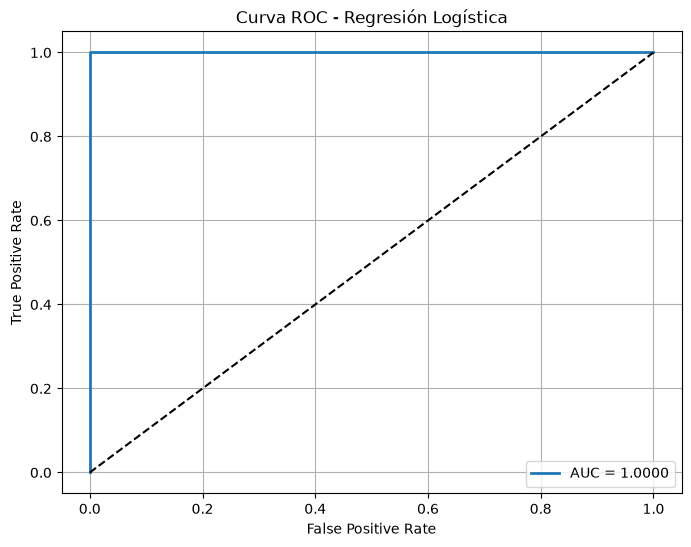

In [17]:
# ==========================================================
# CURVA ROC
# ==========================================================

# Se obtienen las probabilidades de pertenecer a cada clase.
y_proba_test = model.predict_proba(X_test_stdr)

# Se binarizan las etiquetas para problemas multiclase.
y_test_bin = preprocessing.label_binarize(
    y_testing,
    classes=[0, 1, 2]
)

# Se calcula el Área Bajo la Curva (AUC).
auc = metrics.roc_auc_score(
    y_testing,
    y_proba_test,
    multi_class="ovr"
)

# Se calcula la curva ROC para una de las clases.
fpr, tpr, _ = metrics.roc_curve(
    y_test_bin[:, 1],
    y_proba_test[:, 1]
)

# Se crea la gráfica.
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.4f}"
)

# Línea de referencia.
plt.plot([0, 1], [0, 1], "k--")

# Etiquetas.
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")

# Leyenda y cuadrícula.
plt.legend()
plt.grid(True)

# Mostrar la gráfica.
plt.show()